# Trabalho GB 2 - Aplicação de Algoritmos de Aprendizado por Reforço Profundo
## UNISINOS - PPGCA
## Grupo: Alessandro Tyska, Andre Lehdermann, Emilyn Neumann, Weslei Huppes

# 0. Imports e Configurações

In [1]:
import sys
import os
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from examples.train_a2c import train_a2c
from examples.train_ppo import train_ppo
from examples.train_dqn import train_dqn
from tabulate import tabulate
import pandas as pd
import matplotlib as plt
import platform
import psutil
import torch
from stable_baselines3 import A2C
from stable_baselines3 import PPO
from stable_baselines3 import DQN

'''
SKIP_MODEL_TRAINING 
Parâmetro para pular o treinamento dos modelos, apenas exibindo a tabela de resultados extraída
Em tempo de desenolvimento do trabalho ele foi setado para False.
Visando a reprodutibilidade do trabalho, deixamos ele como True apenas sejam reportados os resultados salvos, sem rodar o treino, que é custoso e demorado
'''
SKIP_MODEL_TRAINING = True

def get_hardware_specs():
    """Gathers and returns hardware specifications in a list of lists."""
    specs = []

    # OS Information
    specs.append(["OS", platform.platform()])

    # CPU Information
    specs.append(["CPU", platform.processor()])
    specs.append(["CPU Cores", f"{psutil.cpu_count(logical=False)} (Physical), {psutil.cpu_count(logical=True)} (Logical)"])

    # Memory (RAM) Information
    ram = psutil.virtual_memory()
    specs.append(["Total RAM", f"{ram.total / (1024**3):.2f} GB"])

    # GPU Information
    if torch.cuda.is_available():
        gpu_count = torch.cuda.device_count()
        specs.append(["GPU Found", "Yes (NVIDIA CUDA)"])
        specs.append(["GPU Count", gpu_count])
        for i in range(gpu_count):
            device_name = torch.cuda.get_device_name(i)
            total_mem = torch.cuda.get_device_properties(i).total_memory
            specs.append([f"GPU {i} Name", device_name])
            specs.append([f"GPU {i} Memory", f"{total_mem / (1024**3):.2f} GB"])
    else:
        specs.append(["GPU Found", "No / Not CUDA-enabled"])
        
    return specs

# 1. Algoritmos Implementados

O trabalho implementou três algoritmos de aprendizado por reforço profundo, utilizando a biblioteca stable-baselines3. 
Os algoritmos são:

* A2C (Advantage Actor-Critic)
    * Um algoritmo do tipo Ator-Crítico que atualiza o modelo em lotes (batches) de experiência.

* PPO (Proximal Policy Optimization)
    * Um algoritmo popular que otimiza a política de forma a não se desviar muito da política anterior, garantindo atualizações mais estáveis.

* DQN (Deep Q-Network)
    *  Um algoritmo baseado em valor (value-based) que usa redes neurais profundas para estimar o valor Q (qualidade) de cada ação em um determinado estado.

# 2. Estratégia de Teste dos Algoritmos 

A estratégia experimental foi projetada para cumprir a exigência do trabalho de testar variações nos hiperparâmetros padrão de cada algoritmo.
Para cada um dos três algoritmos (A2C, PPO e DQN), o grupo definiu quatro cenários de experimentação distintos. Cada cenário tinha um objetivo específico, como otimizar a velocidade de aprendizado, aumentar a estabilidade ou incentivar a exploração.

Para isso, os hiperparâmetros relevantes para cada objetivo foram ajustados. Os cenários por algoritmo são:


* A2C
1. Aprendizado Mais Rápido (ajustando learning_rate e n_steps).
2. Maior Estabilidade (ajustando learning_rate e gamma).
3. Exploração Aprimorada (ajustando ent_coef).
4. Ajuste da Estimativa de Vantagem (ajustando gae_lambda).

* PPO
1. Atualizações Mais Rápidas (ajustando n_steps e batch_size).
2. Estabilidade Aumentada (ajustando n_steps e learning_rate).
3. Exploração Aprimorada (ajustando ent_coef).
4. Ajuste do Clipping (ajustando clip_range).

* DQN 
1. Exploração Agressiva (ajustando exploration_fraction).
2. Estabilidade Aumentada (ajustando buffer_size e target_update_interval).
3. Aprendizado Rápido (ajustando buffer_size e train_freq).
4. Atualizações Rápidas da Rede-Alvo (ajustando target_update_interval).

Essa abordagem metódica permitiu ao grupo analisar o impacto de diferentes configurações e justificar a escolha da melhor configuração final para cada algoritmo, conforme exigido pelo relatório.
Vamos agora analisar os testes por algoritmo

## 2.1 A2C - Testes

Nossa lib de treinamento aplica os seguintes valores padrão para os hiperparâmetros:

```python
def train_a2c(
    total_timesteps: int = 2_000_000,
    n_envs: int = 8,
    save_path: str = "models/a2c_drone_delivery",
    best_model_save_path: str = "models/a2c_best",
    gamma: float = 0.99,
    gae_lambda: float = 0.95,
    ent_coef: float = 0.01,
    learning_rate: float = 3e-4,
    n_steps: int = 20,
    seed: int = 42,
    verbose: int = 0,
):
...
```

Abaixo seguem os detalhes dos testes feitos:

### 2.1.1. Aprendizado Mais Rápido (Potencialmente Menos Estável)

Esta configuração visa um aprendizado inicial mais rápido, usando atualizações mais frequentes.

```python
...
train_a2c(
    learning_rate=7e-4,      # A common default in many A2C implementations
    n_steps=5,               # Update more frequently with smaller batches of experience
    n_envs=16,               # Increase parallel environments to compensate for smaller n_steps
    best_model_save_path="models/a2c/faster_learning/"
)
...
```

---

### 2.1.2 Maior Estabilidade e Aprendizado Mais Lento

Esta é uma abordagem conservadora com uma taxa de aprendizado (*learning rate*) mais baixa e *rollouts* maiores pode ajudar a estabilizar o desempenho.

```python
...
train_a2c(
    learning_rate=1e-4,      # A smaller learning rate for more cautious updates
    n_steps=64,              # Larger rollout for lower variance in advantage estimates
    gamma=0.995,             # Slightly higher gamma for longer-term credit assignment
    best_model_save_path="models/a2c/more_stability/"
)
...
```
---

### 2.1.3. Exploração Aprimorada

Para incentivar o agente a descobrir estratégias mais diversas e evitar ficar preso em ótimos locais, você pode aumentar o coeficiente de entropia.

```python
...
train_a2c(
    ent_coef=0.05,           # Increase the weight of the entropy bonus in the loss
    learning_rate=5e-4,      # A moderate learning rate to go with the exploration
    best_model_save_path="models/a2c/enhanced_exploration/"
)
...
```
---

### 2.1.4. Ajustando a Estimativa de Vantagem (GAE)

Esta configuração modifica o parâmetro `gae_lambda` para refinar o *trade-off* (equilíbrio) de viés-variância na estimativa de vantagem, o que pode afetar como o crédito por recompensas é atribuído ao longo do tempo.

```python
...
train_a2c(
    gae_lambda=0.9,          # Closer to TD(0), relies more on the value function (more bias)
    n_steps=32,              # A medium-sized rollout
    best_model_save_path="models/a2c/gae_tuning/"
)
...
```

In [2]:
print("#####################################################")
print("#################### A2C Model ######################")
print("#####################################################\n\n")
if SKIP_MODEL_TRAINING:
    print("SKIP_MODEL_TRAINING = True")
    print("Imprimindo os resultados salvos dos Treinos previamente executados")
    try:
        results_df = pd.read_csv('models/a2c/results.csv')
        results = results_df.to_dict(orient='records')
        print(tabulate(results, headers="keys", tablefmt="grid"))
    except:
        print("ERRO: Arquivo de Resultados 'models/a2c/results.csv' não encontrado.")

else:
    print("SKIP_MODEL_TRAINING = False")
    print("Iniciando Treinamentos nos Cenários Definidos")
    
    results = []
    
    attempt = '2.1.1. Aprendizado Mais Rápido (Potencialmente Menos Estável)'
    print("EXECUTANDO: "+attempt)
    a2c_model, a2c_mean_reward, a2c_std_reward = train_a2c(
                                                            learning_rate=7e-4,      # A common default in many A2C implementations
                                                            n_steps=5,               # Update more frequently with smaller batches of experience
                                                            n_envs=16,               # Increase parallel environments to compensate for smaller n_steps
                                                            total_timesteps=1_000_000,
                                                            best_model_save_path="models/a2c/faster_learning/"
                                                        )
    results.append({'Tentativa': attempt, 'Mean Reward': a2c_mean_reward, 'Std. Dev. Reward': a2c_std_reward})

    attempt = '2.1.2. Maior Estabilidade e Aprendizado Mais Lento'
    print("EXECUTANDO: "+attempt)
    a2c_model, a2c_mean_reward, a2c_std_reward = train_a2c(
                                                            learning_rate=1e-4,      # A smaller learning rate for more cautious updates
                                                            n_steps=64,              # Larger rollout for lower variance in advantage estimates
                                                            gamma=0.995,             # Slightly higher gamma for longer-term credit assignment
                                                            total_timesteps=1_000_000,
                                                            best_model_save_path="models/a2c/more_stability/"
                                                        )
    results.append({'Tentativa': attempt, 'Mean Reward': a2c_mean_reward, 'Std. Dev. Reward': a2c_std_reward})


    attempt = '2.1.3. Exploração Aprimorada'
    print("EXECUTANDO: "+attempt)
    a2c_model, a2c_mean_reward, a2c_std_reward = train_a2c(
                                                            ent_coef=0.05,           # Increase the weight of the entropy bonus in the loss
                                                            learning_rate=5e-4,      # A moderate learning rate to go with the exploration
                                                            total_timesteps=1_000_000,
                                                            best_model_save_path="models/a2c/enhanced_exploration/"
                                                        )
    results.append({'Tentativa': attempt, 'Mean Reward': a2c_mean_reward, 'Std. Dev. Reward': a2c_std_reward})


    attempt = '2.1.4. Ajustando a Estimativa de Vantagem (GAE)'
    print("EXECUTANDO: "+attempt)
    a2c_model, a2c_mean_reward, a2c_std_reward = train_a2c(
                                                            gae_lambda=0.9,          # Closer to TD(0), relies more on the value function (more bias)
                                                            n_steps=32,              # A medium-sized rollout
                                                            total_timesteps=1_000_000,
                                                            best_model_save_path="models/a2c/gae_tuning/"
                                                        )
    results.append({'Tentativa': attempt, 'Mean Reward': a2c_mean_reward, 'Std. Dev. Reward': a2c_std_reward})
    
    results = sorted(results, key=lambda item: item['Mean Reward'], reverse=True)
    results_df = pd.DataFrame(results)
    results_df.to_csv('models/a2c/results.csv', index=False)
    print(tabulate(results, headers="keys", tablefmt="grid"))

#####################################################
#################### A2C Model ######################
#####################################################


SKIP_MODEL_TRAINING = True
Imprimindo os resultados salvos dos Treinos previamente executados
+---------------------------------------------------------------+---------------+--------------------+
| Tentativa                                                     |   Mean Reward |   Std. Dev. Reward |
+===============================================================+===============+====================+
| 2.1.4. Ajustando a Estimativa de Vantagem (GAE)               |         36.45 |            5.02469 |
+---------------------------------------------------------------+---------------+--------------------+
| 2.1.3. Exploração Aprimorada                                  |         34.3  |            6.97209 |
+---------------------------------------------------------------+---------------+--------------------+
| 2.1.1. Aprendizado 

### Vencedor A2C - 2.1.3. Exploração Aprimorada

| Modelo|Cenário Vencedor|Mean Reward|Std. Deviation|Path|
|:---|:---|:---:|:---:|:---|
|A2C|2.1.4. Ajustando a Estimativa de Vantagem (GAE)|36.45|5.02469|`models/a2c/gae_tuning/best_model.zip`|

## 2.2 PPO - Testes

Nossa lib de treinamento aplica os seguintes valores padrão para os hiperparâmetros:

```python
def train_ppo(
    total_timesteps: int = 3_000_000,
    n_envs: int = 8,
    save_path: str = "models/ppo_drone_delivery",
    best_model_save_path: str = "models/ppo_best",
    n_steps: int = 256,
    batch_size: int = 2048,
    gae_lambda: float = 0.95,
    gamma: float = 0.99,
    ent_coef: float = 0.01,
    learning_rate: float = 2.5e-4,
    n_epochs: int = 10,
    clip_range: float = 0.2,
    seed: int = 42,
    verbose: int = 0,
):
...
```
A partir disso, fizemos 4 execuções de treinamento com objetivos diferentes:

### 2.2.1. Atualizações Mais Rápidas & Aprendizado Potencialmente Mais Rápido

Esta configuração usa um buffer de rollout (*n_steps*) menor para atualizar a política com mais frequência. Isso pode acelerar o aprendizado inicial, mas pode introduzir alguma instabilidade. É um bom ponto de partida para ver o quão rápido o agente consegue se adaptar.

```python
...
train_ppo(
    n_steps=128,              # Collect smaller batches of experience for more frequent updates.
    batch_size=1024,          # Adjust batch size to match the smaller rollout buffer.
    learning_rate=3e-4,       # A slightly higher learning rate can pair well with faster updates.
    best_model_save_path="models/ppo/faster_updates/"
)
...
```
---
### 2.2.2. Estabilidade Aumentada & Convergência Mais Suave

Esta abordagem prioriza a estabilidade usando um buffer de rollout (*n_steps*) maior e uma taxa de aprendizado (*learning rate*) menor. Isso fornece estimativas de vantagem mais estáveis e atualizações de política mais cautelosas, o que pode ser benéfico se o treinamento padrão for muito ruidoso ou falhar em convergir.

```python
...
train_ppo(
    n_steps=1024,             # Larger rollout for lower variance in advantage estimates.
    batch_size=2048,          # Use a standard batch size for optimization.
    n_epochs=20,              # Perform more optimization epochs over the larger buffer.
    learning_rate=1e-4,       # A smaller learning rate for more conservative updates.
    best_model_save_path="models/ppo/increased_stability/"
)
...
```
---

### 2.2.3. Exploração Aprimorada

Se o agente ficar preso em uma estratégia subótima (por exemplo, nunca tentar a entrega), aumentar o coeficiente de entropia (``ent_coef``) pode ajudar. Isso incentiva o agente a explorar ações mais diversas em vez de se comprometer prematuramente com uma política falha

```python
...
train_ppo(
    ent_coef=0.05,            # Significantly increase the weight of the entropy bonus.
    learning_rate=2e-4,       # A slightly lower learning rate to balance the exploratory policy.
    best_model_save_path="models/ppo/enhanced_exploration/"
)
...
```

---

### 2.2.4. Ajustando o Clipping do PPO

O `clip_range` é um parâmetro central no PPO que limita o quanto a política pode mudar em uma atualização. Um valor menor torna as atualizações mais conservadoras, o que pode prevenir colapsos no desempenho. Um valor maior permite atualizações mais agressivas.

```python
...
train_ppo(
    clip_range=0.1,           # A smaller clip range for more conservative policy updates.
    n_epochs=15,              # More epochs to compensate for the smaller update steps.
    best_model_save_path="models/ppo/conservative_clipping/"
)
...
```

In [3]:
print("#####################################################")
print("#################### PPO Model ######################")
print("#####################################################\n\n")
if SKIP_MODEL_TRAINING:
    print("SKIP_MODEL_TRAINING = True")
    print("Imprimindo os resultados salvos dos Treinos previamente executados")
    try:
        results_df = pd.read_csv('models/ppo/results.csv')
        results = results_df.to_dict(orient='records')
        print(tabulate(results, headers="keys", tablefmt="grid"))
    except:
        print("ERRO: Arquivo de Resultados 'models/ppo/results.csv' não encontrado.")

else:
    print("SKIP_MODEL_TRAINING = False")
    print("Iniciando Treinamentos nos Cenários Definidos")

    results = []  
    
    attempt = '2.2.1. Atualizações Mais Rápidas & Aprendizado Potencialmente Mais Rápido'
    print("EXECUTANDO: "+attempt)
    ppo_model, ppo_mean_reward, ppo_std_reward = train_ppo(
                                                            n_steps=128,              # Collect smaller batches of experience for more frequent updates.
                                                            batch_size=1024,          # Adjust batch size to match the smaller rollout buffer.
                                                            learning_rate=3e-4,       # A slightly higher learning rate can pair well with faster updates.
                                                            total_timesteps=1_000_000,
                                                            best_model_save_path="models/ppo/faster_updates/"
                                                        )
    results.append({'Tentativa': attempt, 'Mean Reward': ppo_mean_reward, 'Std. Dev. Reward': ppo_std_reward})

    attempt = '2.2.2. Estabilidade Aumentada & Convergência Mais Suave'
    print("EXECUTANDO: "+attempt)
    ppo_model, ppo_mean_reward, ppo_std_reward = train_ppo(
                                                            n_steps=1024,             # Larger rollout for lower variance in advantage estimates.
                                                            batch_size=2048,          # Use a standard batch size for optimization.
                                                            n_epochs=20,              # Perform more optimization epochs over the larger buffer.
                                                            learning_rate=1e-4,       # A smaller learning rate for more conservative updates.
                                                            total_timesteps=1_000_000,
                                                            best_model_save_path="models/ppo/increased_stability/"
                                                        )
    results.append({'Tentativa': attempt, 'Mean Reward': ppo_mean_reward, 'Std. Dev. Reward': ppo_std_reward})

    attempt = '2.2.3. Exploração Aprimorada'
    print("EXECUTANDO: "+attempt)
    ppo_model, ppo_mean_reward, ppo_std_reward = train_ppo(
                                                            ent_coef=0.05,            # Significantly increase the weight of the entropy bonus.
                                                            learning_rate=2e-4,       # A slightly lower learning rate to balance the exploratory policy.
                                                            total_timesteps=1_000_000,
                                                            best_model_save_path="models/ppo/enhanced_exploration/"
                                                        )
    results.append({'Tentativa': attempt, 'Mean Reward': ppo_mean_reward, 'Std. Dev. Reward': ppo_std_reward})

    attempt = '2.2.4. Ajustando o Clipping do PPO'
    print("EXECUTANDO: "+attempt)
    ppo_model, ppo_mean_reward, ppo_std_reward = train_ppo(
                                                            clip_range=0.1,           # A smaller clip range for more conservative policy updates.
                                                            n_epochs=15,              # More epochs to compensate for the smaller update steps.
                                                            total_timesteps=1_000_000,
                                                            best_model_save_path="models/ppo/conservative_clipping/"
                                                        )
    results.append({'Tentativa': attempt, 'Mean Reward': ppo_mean_reward, 'Std. Dev. Reward': ppo_std_reward})

    results = sorted(results, key=lambda item: item['Mean Reward'], reverse=True)
    results_df = pd.DataFrame(results)
    results_df.to_csv('models/ppo/results.csv', index=False)
    print(tabulate(results, headers="keys", tablefmt="grid"))


#####################################################
#################### PPO Model ######################
#####################################################


SKIP_MODEL_TRAINING = True
Imprimindo os resultados salvos dos Treinos previamente executados
+---------------------------------------------------------------------------+---------------+--------------------+
| Tentativa                                                                 |   Mean Reward |   Std. Dev. Reward |
+===========================================================================+===============+====================+
| 2.2.4. Ajustando o Clipping do PPO                                        |         33.45 |            8.82312 |
+---------------------------------------------------------------------------+---------------+--------------------+
| 2.2.1. Atualizações Mais Rápidas & Aprendizado Potencialmente Mais Rápido |         33.35 |           10.1009  |
+---------------------------------------------------

### Vencedor PPO - 2.2.2. Estabilidade Aumentada & Convergência Mais Suave

| Modelo|Cenário Vencedor|Mean Reward|Std. Deviation|Path|
|:---|:---|:---:|:---:|:---|
|PPO|2.2.4. Ajustando o Clipping do PPO|33.45|8.82312|`models/ppo/conservative_clipping/best_model.zip`|


## 2.3 DQN - Testes

#### IMPORTANTE: Adequação dos Hiperparâmetros para o Hardware Executado

Fizemos testes iniciais com um conjunto de parâmetros que não ficavam condizentes com o hardware utilizado, levando a um tempo impraticável para execução do treinamento e erros de estouro de memória da GPU. 

Desta forma, repensamos os parâmetros para adaptar a realidade do hardware. Mantemos comentado no código a tentativa inicial para comparativo.

In [4]:
# Get and print the hardware specifications
hardware_specs = get_hardware_specs()
print("--- Hardware Specifications ---")
print(tabulate(hardware_specs, headers=["Component", "Specification"], tablefmt="grid"))

--- Hardware Specifications ---
+--------------+--------------------------------------------------------------+
| Component    | Specification                                                |
+==============+==============================================================+
| OS           | Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39 |
+--------------+--------------------------------------------------------------+
| CPU          | x86_64                                                       |
+--------------+--------------------------------------------------------------+
| CPU Cores    | 8 (Physical), 16 (Logical)                                   |
+--------------+--------------------------------------------------------------+
| Total RAM    | 15.58 GB                                                     |
+--------------+--------------------------------------------------------------+
| GPU Found    | Yes (NVIDIA CUDA)                                            |
+-------

Nossa lib de treinamento aplica os seguintes valores padrão para os hiperparâmetros:

```python
def train_dqn(
    total_timesteps: int = 1_000_000,
    save_path: str = "models/dqn_drone_delivery",
    best_model_save_path: str = "models/dqn_best",
    buffer_size: int = 100_000,
    learning_starts: int = 10_000,
    target_update_interval: int = 1_000,
    train_freq: int = 4,
    exploration_fraction: float = 0.2,
    seed: int = 42,
    verbose: int = 0,
):
...
```
A partir disso, fizemos 4 execuções de treinamento com objetivos diferentes:

### 2.3.1. Exploração Agressiva

Esta configuração incentiva o agente a explorar mais amplamente e por uma porção maior do treinamento. Ela aumenta a fração do treinamento dedicada a atenuar (*annealing*) a taxa de exploração e começa a aprender mais cedo.

```python
...
train_dqn(
        exploration_fraction=0.4,         # Keep and Update: Dedicate a large portion to exploration
        learning_starts=5000,             # Keep: Start learning earlier
        train_freq=8,                     # Update less frequently to speed up training
        total_timesteps=750_000,          # Reduced from 1M for a faster run
        buffer_size=80_000,               # Smaller buffer to save memory
        best_model_save_path="models/dqn/aggressive_exploration/"
    )
...
```
---
### 2.3.2. Estabilidade Aumentada com um Buffer Maior

Esta configuração prioriza a estabilidade do aprendizado. Um buffer de replay (*replay buffer*) muito maior fornece experiências mais diversas e decorrelacionadas, e uma atualização mais lenta da rede-alvo (*target network*) impede que os valores-alvo mudem muito rapidamente, o que pode ajudar a estabilizar o treinamento.

```python
...
train_dqn(
        buffer_size=150_000,              # Keep and Update: Reduced from 500k to fit in memory, but still large                                                        
        target_update_interval=4000,      # Keep and Update: Update target network less frequently
        train_freq=4,                     # Keep default training frequency
        total_timesteps=800_000,          # Reduced from 1M
        best_model_save_path="models/dqn/increased_stability/"
    )
...
```
---

### 2.3.3. Aprendizado Mais Rápido da Experiência Recente

Esta configuração faz o agente aprender mais das transições recentes usando um buffer de replay menor. Isso pode acelerar a adaptação, mas pode levar ao `esquecimento catastrófico` (*catastrophic forgetting*) se o buffer for muito pequeno. É um *trade-off* (uma troca) entre reatividade e estabilidade.

```python
...
train_dqn(
        buffer_size=20_000,               # Keep: Small buffer to focus on recent data
        learning_starts=2000,             # Keep: Start learning early
        train_freq=8,                     # Update: Changed from 1 to 8 to prevent memory overload and speed up
        total_timesteps=800_000,          # Reduced from 1M
        best_model_save_path="models/dqn/fast_adaptation/"
    )
...
```

---

### 2.3.4. Atualizações Rápidas da Rede-Alvo

Este cenário reduz drasticamente o intervalo de atualização da rede-alvo. Embora muitas vezes menos estável, atualizações mais rápidas podem, às vezes, ajudar em ambientes onde as estimativas de valor precisam se propagar rapidamente. Esta é uma abordagem mais agressiva em comparação com a padrão.

```python
...
train_dqn(
        target_update_interval=500,       # Keep and Update: Update target network frequently
        train_freq=8,                     # Keep and Update: Changed from 2 to 8 to reduce computational load
        total_timesteps=750_000,          # Reduced from 1M
        buffer_size=80_000,               # Reduced buffer for lower memory usage
        best_model_save_path="models/dqn/rapid_target_updates/"
    )
...
```

In [5]:
print("#####################################################")
print("#################### DQN Model ######################")
print("#####################################################\n\n")
if SKIP_MODEL_TRAINING:
    print("SKIP_MODEL_TRAINING = True")
    print("Imprimindo os resultados salvos dos Treinos previamente executados")
    try:
        results_df = pd.read_csv('models/dqn/results.csv')
        results = results_df.to_dict(orient='records')
        print(tabulate(results, headers="keys", tablefmt="grid"))
    except:
        print("ERRO: Arquivo de Resultados 'models/dqn/results.csv' não encontrado.")

else:
    print("SKIP_MODEL_TRAINING = False")
    print("Iniciando Treinamentos nos Cenários Definidos")

    results = []  

    attempt = '2.3.1. Exploração Agressiva'
    print("EXECUTANDO: "+attempt)
    '''
    dqn_model, dqn_mean_reward, dqn_std_reward = train_dqn(
                                                        exploration_fraction=0.5,  # Dedicate 50% of training to exploration decay (default is 0.2)
                                                        learning_starts=5000,      # Start learning earlier (default is 10,000)
                                                        best_model_save_path="models/dqn/aggressive_exploration/"
                                                    )
    '''
    dqn_model, dqn_mean_reward, dqn_std_reward = train_dqn(
                                                        exploration_fraction=0.4,         # Keep and Update: Dedicate a large portion to exploration
                                                        learning_starts=5000,             # Keep: Start learning earlier
                                                        train_freq=8,                     # Update less frequently to speed up training
                                                        total_timesteps=1_200_000,          # Reduced from 1M for a faster run
                                                        buffer_size=80_000,               # Smaller buffer to save memory
                                                        best_model_save_path="models/dqn/aggressive_exploration/"
                                                    )

    results.append({'Tentativa': attempt, 'Mean Reward': dqn_mean_reward, 'Std. Dev. Reward': dqn_std_reward})

    attempt = '2.3.2. Estabilidade Aumentada com um Buffer Maior'
    print("EXECUTANDO: "+attempt)
    '''
    dqn_model, dqn_mean_reward, dqn_std_reward = train_dqn(
                                                        buffer_size=500_000,           # Increase buffer for more experience diversity (default is 100k)
                                                        target_update_interval=5000,   # Update the target network less frequently for stability (default is 1k)
                                                        best_model_save_path="models/dqn/increased_stability/"
                                                    )
    '''
    dqn_model, dqn_mean_reward, dqn_std_reward = train_dqn(
                                                        buffer_size=150_000,              # Keep and Update: Reduced from 500k to fit in memory, but still large                                                        
                                                        target_update_interval=4000,      # Keep and Update: Update target network less frequently
                                                        train_freq=4,                     # Keep default training frequency
                                                        total_timesteps=1_200_000,          # Reduced from 1M
                                                        best_model_save_path="models/dqn/increased_stability/"
                                                    )

    results.append({'Tentativa': attempt, 'Mean Reward': dqn_mean_reward, 'Std. Dev. Reward': dqn_std_reward})

    attempt = '2.3.3. Aprendizado Mais Rápido da Experiência Recente'
    print("EXECUTANDO: "+attempt)
    '''
    dqn_model, dqn_mean_reward, dqn_std_reward = train_dqn(
                                                        buffer_size=20_000,            # Smaller buffer makes learning more 'on-policy'
                                                        learning_starts=2000,          # Start learning very early
                                                        train_freq=1,                  # Update the model after every single step
                                                        best_model_save_path="models/dqn/fast_adaptation/"
                                                    )
    '''
    dqn_model, dqn_mean_reward, dqn_std_reward = train_dqn(
                                                        buffer_size=20_000,               # Keep: Small buffer to focus on recent data
                                                        learning_starts=2000,             # Keep: Start learning early
                                                        train_freq=8,                     # Update: Changed from 1 to 8 to prevent memory overload and speed up
                                                        total_timesteps=1_200_000,          # Reduced from 1M
                                                        best_model_save_path="models/dqn/fast_adaptation/"
                                                    )

    results.append({'Tentativa': attempt, 'Mean Reward': dqn_mean_reward, 'Std. Dev. Reward': dqn_std_reward})

    attempt = '2.3.4. Atualizações Rápidas da Rede-Alvo'
    print("EXECUTANDO: "+attempt)
    '''
    dqn_model, dqn_mean_reward, dqn_std_reward = train_dqn(
                                                        target_update_interval=250,    # Update target network much more frequently (default is 1000)
                                                        train_freq=2,                  # Update model every 2 steps
                                                        best_model_save_path="models/dqn/rapid_target_updates/"
                                                    )
    '''
    dqn_model, dqn_mean_reward, dqn_std_reward = train_dqn(
                                                        target_update_interval=500,       # Keep and Update: Update target network frequently
                                                        train_freq=8,                     # Keep and Update: Changed from 2 to 8 to reduce computational load
                                                        total_timesteps=1_200_000,          # Reduced from 1M
                                                        buffer_size=80_000,               # Reduced buffer for lower memory usage
                                                        best_model_save_path="models/dqn/rapid_target_updates/"
                                                    )

    results.append({'Tentativa': attempt, 'Mean Reward': dqn_mean_reward, 'Std. Dev. Reward': dqn_std_reward})

    results = sorted(results, key=lambda item: item['Mean Reward'], reverse=True)
    results_df = pd.DataFrame(results)
    results_df.to_csv('models/dqn/results.csv', index=False)
    print(tabulate(results, headers="keys", tablefmt="grid"))

#####################################################
#################### DQN Model ######################
#####################################################


SKIP_MODEL_TRAINING = True
Imprimindo os resultados salvos dos Treinos previamente executados
+-------------------------------------------------------+---------------+--------------------+
| Tentativa                                             |   Mean Reward |   Std. Dev. Reward |
+=======================================================+===============+====================+
| 2.3.2. Estabilidade Aumentada com um Buffer Maior     |          34.4 |            4.75815 |
+-------------------------------------------------------+---------------+--------------------+
| 2.3.3. Aprendizado Mais Rápido da Experiência Recente |         -30   |            0       |
+-------------------------------------------------------+---------------+--------------------+
| 2.3.1. Exploração Agressiva                           |         -31   |    

### Vencedor DQN - 2.3.2. Estabilidade Aumentada com um Buffer Maior

| Modelo|Cenário Vencedor|Mean Reward|Std. Deviation|Path|
|:---|:---|:---:|:---:|:---|
|DQN|2.3.2. Estabilidade Aumentada com um Buffer Maior|34.4|4.75815|`models/dqn/increased_stability/best_model.zip`|

# 3. Rodando o Melhor Cenário de Cada Modelo contra o Ambiente DroneDelivery

## Resumo dos cenários com melhores recompensas

| Modelo|Cenário Vencedor|Mean Reward|Std. Deviation|Path|
|:---|:---|:---:|:---:|:---|
|A2C|2.1.4. Ajustando a Estimativa de Vantagem (GAE)|36.45|5.02469|`models/a2c/gae_tuning/best_model.zip`|
|PPO|2.2.4. Ajustando o Clipping do PPO|33.45|8.82312|`models/ppo/conservative_clipping/best_model.zip`|
|DQN|2.3.2. Estabilidade Aumentada com um Buffer Maior|34.4|4.75815|`models/dqn/increased_stability/best_model.zip`|

In [6]:
import matplotlib.pyplot as plt
import os
import sys

project_root = os.path.abspath('../')
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from examples.replay_sb3_policy_notebook import replay_notebook_policy, default_model_path


def run_replay_in_notebook(algo: str, model_path: str, description: str):
    """
    A wrapper function to run and render a pre-trained SB3 model replay in a notebook.

    This function sets up the rendering environment and calls the core replay logic.

    :param algo: The algorithm name ('ppo', 'a2c', 'dqn').
    :param model_path: Path to the saved model .zip file.
    :param description: A description of the replay attempt for logging.
    """
    print("=" * 70)
    print(f"ATTEMPT: {description}")
    print(f"  Algorithm: {algo.upper()}")
    print(f"  Model Path: {model_path}")
    print("=" * 70)

    if not os.path.exists(model_path):
        print(f"SKIPPING: Model file not found at '{model_path}'.")
        print("Please train the model first by running the corresponding 'train_*.py' script.")
        print("-" * 70 + "\n")
        return

    # Create a matplotlib figure and axis for rendering.
    # The replay function will handle clearing and updating the plot for animation.
    fig, ax = plt.subplots(figsize=(6, 6))

    try:
        # Run the replay using the function from the new library
        replay_notebook_policy(
            algo=algo,
            model_path=model_path,
            render_ax=ax,
            deterministic=True,  # Use deterministic actions for consistent replay
            sleep=0.1            # Animation speed (seconds between frames)
        )
    except Exception as e:
        print(f"An error occurred during replay: {e}")
    finally:
        # Close the plot to free up memory and prevent it from lingering in the notebook
        plt.close(fig)
        print("-" * 70 + "\n")


# --- Example Usage ---
# This code block demonstrates how to run replays for PPO, A2C, and DQN
# using their default trained model paths.

if __name__ == '__main__':
    # Define the algorithms to test
    algos_to_run = ["ppo", "a2c", "dqn"]

    for algorithm in algos_to_run:
        # The `default_model_path` function automatically finds the best model
        model_file = default_model_path(algorithm)

        run_replay_in_notebook(
            algo=algorithm,
            model_path=model_file,
            description=f"Replay of pre-trained {algorithm.upper()} model"
        )


ATTEMPT: Replay of pre-trained PPO model
  Algorithm: PPO
  Model Path: models/ppo_best/best_model.zip
SKIPPING: Model file not found at 'models/ppo_best/best_model.zip'.
Please train the model first by running the corresponding 'train_*.py' script.
----------------------------------------------------------------------

ATTEMPT: Replay of pre-trained A2C model
  Algorithm: A2C
  Model Path: models/a2c_best/best_model.zip
SKIPPING: Model file not found at 'models/a2c_best/best_model.zip'.
Please train the model first by running the corresponding 'train_*.py' script.
----------------------------------------------------------------------

ATTEMPT: Replay of pre-trained DQN model
  Algorithm: DQN
  Model Path: models/dqn_best/best_model.zip
SKIPPING: Model file not found at 'models/dqn_best/best_model.zip'.
Please train the model first by running the corresponding 'train_*.py' script.
----------------------------------------------------------------------



## 3.1 A2C - Executando o Melhor contra o Ambiente

ATTEMPT: 2.1.4. Ajustando a Estimativa de Vantagem (GAE)
  Algorithm: A2C
  Model Path: models/a2c/gae_tuning/best_model.zip


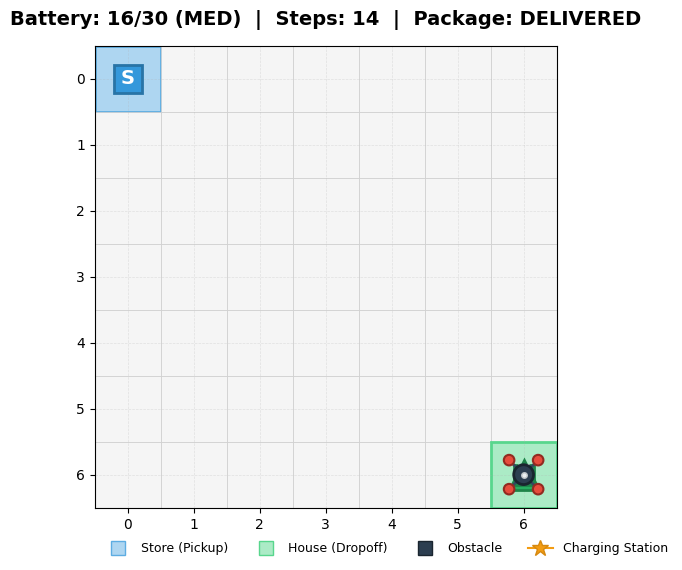

Replay finished.
  Total Steps: 14
  Total Return: 36.00
  Delivered: Yes
----------------------------------------------------------------------



In [7]:
run_replay_in_notebook('a2c', 'models/a2c/gae_tuning/best_model.zip', '2.1.4. Ajustando a Estimativa de Vantagem (GAE)')

## 3.2 PPO - Executando o Melhor contra o Ambiente

ATTEMPT: 2.2.4. Ajustando o Clipping do PPO
  Algorithm: PPO
  Model Path: models/ppo/conservative_clipping/best_model.zip


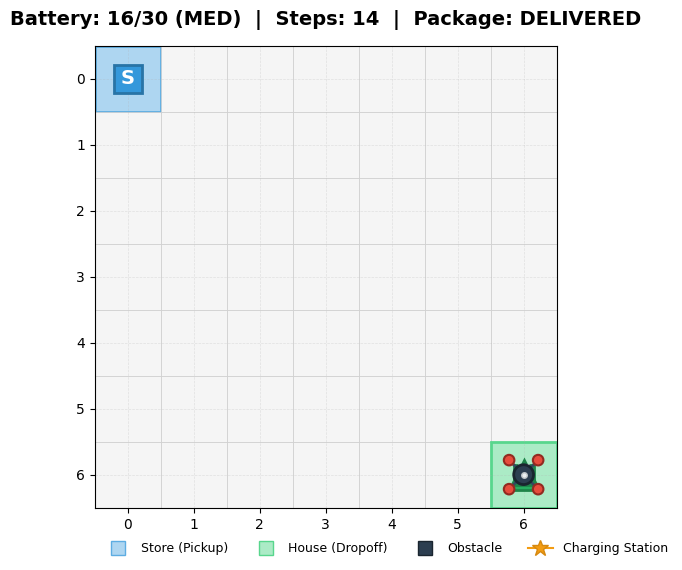

Replay finished.
  Total Steps: 14
  Total Return: 36.00
  Delivered: Yes
----------------------------------------------------------------------



In [8]:
run_replay_in_notebook('ppo', 'models/ppo/conservative_clipping/best_model.zip', '2.2.4. Ajustando o Clipping do PPO')

## 3.3 DQN - Executando o Melhor contra o Ambiente

ATTEMPT: 2.3.2. Estabilidade Aumentada com um Buffer Maior
  Algorithm: DQN
  Model Path: models/dqn/increased_stability/best_model.zip


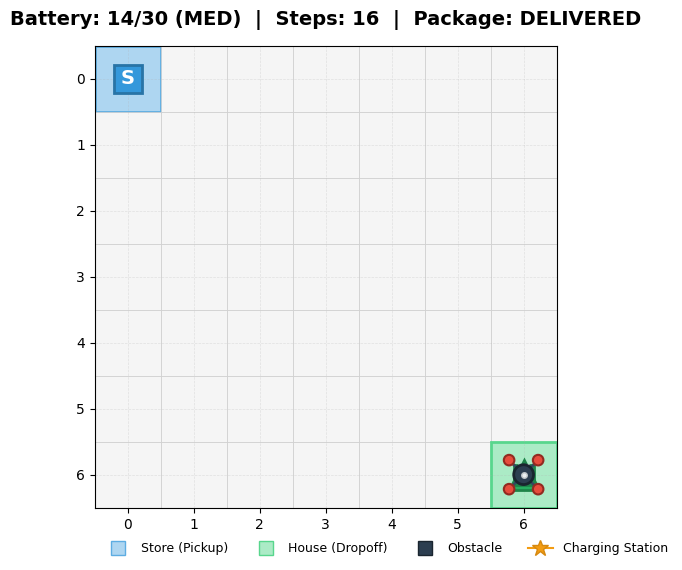

Replay finished.
  Total Steps: 16
  Total Return: 34.00
  Delivered: Yes
----------------------------------------------------------------------



In [9]:
run_replay_in_notebook('dqn', 'models/dqn/increased_stability/best_model.zip', '2.3.2. Estabilidade Aumentada com um Buffer Maior')